In [2]:
# 데이터 베이스 연결

import os
from dotenv import load_dotenv
import mysql.connector as mc
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

API_KEY = os.getenv('SEOUL_DATA_KEY')

DB_CONFIG = {
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
    'database': 'bike_db'
}

# DB 연결
conn = mc.connect(**DB_CONFIG)
cursor = conn.cursor()

print("DB 서버 연결:", conn.is_connected())

# 분석용 칼럼 선택

query = """
SELECT
    d.station_name,
    d.latitude,
    d.longitude,
    f.bike_count,
    f.shared
FROM fact_bike_status f
JOIN dim_station d ON f.station_id = d.station_id
"""

df = pd.read_sql(query, conn)

DB 서버 연결: True


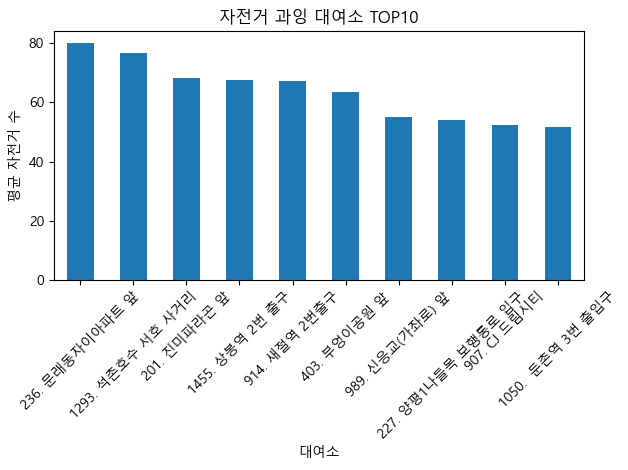

In [5]:
import matplotlib.pyplot as plt

# 한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

high_station = (
    df.groupby('station_name')['bike_count']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
high_station.plot(kind='bar')
plt.title("자전거 과잉 대여소 TOP10")
plt.xlabel("대여소")
plt.ylabel("평균 자전거 수")
# x축 글자 기울이기 (대여소 이름 길어서)
plt.xticks(rotation=45)
# 자동으로 여백 조정  / 레이아웃 정리
plt.tight_layout()
plt.show()

In [3]:
import folium

# 서울 중심 좌표
map = folium.Map(location=[37.56, 126.97], zoom_start=12)

# 평균값 계산
station_avg = (
    df.groupby(['station_name','latitude','longitude'])['bike_count']
    .mean()
    .reset_index()
)

for _, row in station_avg.iterrows():
    # 색상 기준
    if row['bike_count'] < 5:
        color = 'red'     # 부족
    elif row['bike_count'] > 15:
        color = 'blue'    # 많음
    else:
        color = 'green'   # 보통

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color,
        fill=True,
        popup=f"{row['station_name']} ({row['bike_count']:.1f})"
    ).add_to(map)

# 웹 페이지 연결 방식이라 렌더링 제한.. 대신 별도 파일로 저장
map.save("bike_map.html")